# Notebook 16 — Cross-Validation of DINNDeep's r=1.000 Result (Track 1 v1.5)

**The honesty check on nb15.** Notebook 15 reported DINNDeep achieving r = 1.000 on Eq Pacific FeT, with ~3000× lower loss than the SST-only DINN baseline. With ~9.4K params and 1071 cells × 6 outputs = 6.4K unknowns, the network approaches parameter parity. That headline result needs a sanity check: is DINNDeep learning a generalizable environment → Carroll-6 mapping, or is it near-memorizing the FeT pattern via degenerate parameter sets?

**Two cross-validation experiments.** Same DINNDeep architecture, same Eq Pacific FeT target, same hyperparameters as nb15. Only difference: hold out cells from the loss and evaluate r on them separately.

1. **Random 80/20 split** — interpolation test. Hold out 20% of ocean cells at random; the held-out cells typically have neighbours in the train set, so the network only needs to interpolate the env → params function across nearby points.
2. **Block hold-out (western 2/3 train, eastern 1/3 test)** — extrapolation test. The held-out cells form a contiguous block, forcing the network to extrapolate the env → params function across a region it never saw.

**How to read the results:**

| Random r | Block r | Interpretation |
|---|---|---|
| High (~0.9+) | High (~0.9+) | Strong generalization — DINNDeep learned a real mapping |
| High | Low | Interpolation works, extrapolation fails — typical for high-capacity nets on smooth fields |
| Low | Low | Memorization — the r=1.000 in nb15 was overfitting |

Either of the lower-right outcomes (extrapolation fails OR full memorization) would mean the recovered Carroll-6 maps from nb15 should be treated as a high-capacity interpolant, not a calibration. If both r values stay high, DINNDeep's improvement over baseline DINN is real generalization that's worth rolling out to the other notebooks.

Same warning as nb15 about the recovery ceiling: even if cross-validation passes, the recovered Carroll-6 means in nb15 don't match Carroll's published values — the box-model proxy is the ultimate ceiling, not the network.

**Stacked PR.** Depends on PR #26 (DINNDeep + nb15).

In [1]:
import sys
import time
import warnings
from pathlib import Path

_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_src = _repo_root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

warnings.filterwarnings("ignore", message="Couldn't find available_diagnostics.log")
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import binned_statistic_2d

from darwindiff.carroll6 import (
    PARAM_BOUNDS,
    PARAM_NAMES,
    bounded_params,
    carroll6_step,
)
from darwindiff.diagnostics import format_pearson, safe_pearson_r
from darwindiff.ecco_darwin_loader import (
    EQUATORIAL_PACIFIC_AOI,
    open_bin_average,
    subset_aoi,
    time_mean,
)
from darwindiff.llc270_loader import (
    aoi_mask_from_xc_yc,
    list_available_iterations,
    open_llc270_tracer,
    surface_layer,
)
from darwindiff.networks import DINNDeep

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}, GPU={torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no'}")

PyTorch 2.11.0+cu128, GPU=NVIDIA GeForce RTX 5090 Laptop GPU


## 1. Reproduce nb15's data (FeT target + 4-channel covariates)

In [2]:
MONTHLY_ROOT = r"D:\ecco_darwin_v5\output\monthly"
GRID_DIR = r"D:\ecco_darwin_v5\grid"
BIN_AVG_PATH = r"D:\ecco_darwin_v5\bin_average\v05_ECCO-Darwin_bin_average_1x1_deg.nc"
AOI = EQUATORIAL_PACIFIC_AOI

iters = list_available_iterations(MONTHLY_ROOT, "FeT")
fet_ds = open_llc270_tracer(MONTHLY_ROOT, GRID_DIR, "FeT", iters=iters)
fet_surf = surface_layer(fet_ds)
fet_mean = fet_surf.FeT.mean(dim="time", skipna=True).values
xc_native = fet_surf.XC.values; yc_native = fet_surf.YC.values
good = aoi_mask_from_xc_yc(xc_native, yc_native, AOI.lat_min, AOI.lat_max, AOI.lon_min, AOI.lon_max) & np.isfinite(fet_mean) & (fet_mean != 0)
lat_edges = np.arange(AOI.lat_min - 0.5, AOI.lat_max + 0.5 + 0.001, 1.0)
lon_edges = np.arange(AOI.lon_min - 0.5, AOI.lon_max + 0.5 + 0.001, 1.0)
fet_binned, _, _, _ = binned_statistic_2d(yc_native[good], xc_native[good], fet_mean[good], statistic="mean", bins=[lat_edges, lon_edges])

ds_bin = open_bin_average(BIN_AVG_PATH)
eqpac_clim = time_mean(subset_aoi(ds_bin, AOI))
sst = eqpac_clim.SST.values; mld = eqpac_clim.mldDepth.values; wind = eqpac_clim.windSpeed.values
lat_1d = eqpac_clim.lat.values
lat_2d = np.broadcast_to(lat_1d[:, None], sst.shape).astype(np.float64)
ocean_mask = np.isfinite(sst) & np.isfinite(mld) & np.isfinite(wind) & np.isfinite(fet_binned)
n_ocean = int(ocean_mask.sum())
print(f"Ocean cells: {n_ocean} (same as nb15)")

# Build the 4-channel env tensor (z-scored over ocean cells)
def normalize(arr):
    o = arr[ocean_mask]
    return np.where(ocean_mask, (arr - o.mean()) / max(o.std(), 1e-9), 0.0).astype(np.float32)
env_4ch = torch.tensor(np.stack([normalize(sst), normalize(mld), normalize(wind), normalize(lat_2d)], axis=0), dtype=torch.float32)
fet_target = torch.tensor(np.where(ocean_mask, fet_binned, 1.0), dtype=torch.float32)
mask_t = torch.tensor(ocean_mask, dtype=torch.bool)
H, W = env_4ch.shape[1], env_4ch.shape[2]
state0 = torch.tensor([5.0e-4, 1.0, 1.0, 0.5, 0.025]).reshape(5, 1, 1).expand(5, H, W).contiguous()

env_4ch_dev = env_4ch.to(device); state0_dev = state0.to(device); fet_target_dev = fet_target.to(device); mask_dev = mask_t.to(device)
bounds_dev = PARAM_BOUNDS.to(device)

fet_ocean = fet_target_dev[mask_dev]
target_mean = fet_ocean.mean(); target_std = fet_ocean.std().clamp(min=1e-6)
target_z = (fet_target_dev - target_mean) / target_std
print(f"env_4ch shape: {tuple(env_4ch.shape)}, FeT target z: mean={float(target_mean):.3e}, std={float(target_std):.3e}")

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


Ocean cells: 1071 (same as nb15)


env_4ch shape: (4, 21, 51), FeT target z: mean=7.290e-06, std=1.744e-05


## 2. Build the two CV splits — random 80/20 + block (western 2/3 vs eastern 1/3)

Random 80/20 split:  train=857, test=214
Block split (W 2/3): train=714, test=357, split column=34


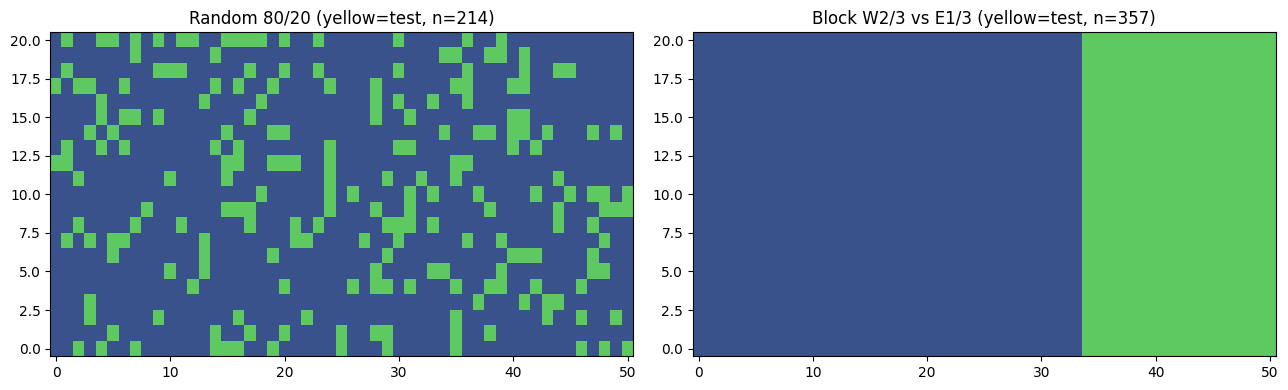

In [3]:
rng = np.random.default_rng(0)

# === Random 80/20 split ===
ocean_idx = np.where(ocean_mask.flatten())[0]
n_test_random = int(0.2 * n_ocean)
test_idx_random = rng.choice(ocean_idx, n_test_random, replace=False)
train_mask_random = ocean_mask.copy()
train_mask_random.flat[test_idx_random] = False
test_mask_random = ocean_mask & ~train_mask_random

# === Block split: western 2/3 train, eastern 1/3 test ===
n_lon = ocean_mask.shape[1]
split_col = (n_lon * 2) // 3
lon_block_mask = np.zeros_like(ocean_mask)  # True = west (train side)
lon_block_mask[:, :split_col] = True
train_mask_block = ocean_mask & lon_block_mask
test_mask_block = ocean_mask & ~lon_block_mask

print(f"Random 80/20 split:  train={int(train_mask_random.sum())}, test={int(test_mask_random.sum())}")
print(f"Block split (W 2/3): train={int(train_mask_block.sum())}, test={int(test_mask_block.sum())}, split column={split_col}")

# Visualize the splits
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
viz = np.full(ocean_mask.shape, 0.0)
viz[train_mask_random] = 1; viz[test_mask_random] = 2; viz[~ocean_mask] = np.nan
axes[0].imshow(viz, origin="lower", aspect="auto", cmap="viridis", vmin=0.5, vmax=2.5)
axes[0].set_title(f"Random 80/20 (yellow=test, n={int(test_mask_random.sum())})")
viz2 = np.full(ocean_mask.shape, 0.0)
viz2[train_mask_block] = 1; viz2[test_mask_block] = 2; viz2[~ocean_mask] = np.nan
axes[1].imshow(viz2, origin="lower", aspect="auto", cmap="viridis", vmin=0.5, vmax=2.5)
axes[1].set_title(f"Block W2/3 vs E1/3 (yellow=test, n={int(test_mask_block.sum())})")
plt.tight_layout(); plt.show()

## 3. Train DINNDeep on each split (loss masked to train cells only)

In [4]:
DT, N_STEPS, N_EPOCHS = 0.25, 200, 1500

def train_with_mask(train_mask: np.ndarray, seed: int = 0) -> dict:
    """Train DINNDeep with loss restricted to train_mask cells. Forward pass
    still touches all cells (because the per-cell network outputs at every cell);
    only the loss aggregation is restricted."""
    train_mask_t = torch.tensor(train_mask, dtype=torch.bool).to(device)
    n_train = int(train_mask_t.sum())
    torch.manual_seed(seed)
    net = DINNDeep(n_input_channels=4, hidden_dim=32, n_outputs=6, n_blocks=4).to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=5e-3)
    losses = []
    if device == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    for epoch in range(N_EPOCHS):
        optimizer.zero_grad()
        params = bounded_params(net(env_4ch_dev), bounds_dev)
        state = state0_dev
        for _ in range(N_STEPS):
            state = carroll6_step(state, params, DT)
        dfe = state[0]
        # Z-score using TRAIN cells only (the test cells are unseen)
        dfe_train = dfe[train_mask_t]
        dfe_z = (dfe - dfe_train.mean()) / dfe_train.std().clamp(min=1e-6)
        residual = (dfe_z - target_z) * train_mask_t.to(dfe.dtype)
        loss = (residual ** 2).sum() / train_mask_t.sum().to(residual.dtype)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
        if (epoch + 1) % 250 == 0:
            print(f"    epoch {epoch+1:4d}  loss = {loss.item():.4e}")
    if device == "cuda": torch.cuda.synchronize()
    elapsed = time.time() - t0
    with torch.no_grad():
        params_final = bounded_params(net(env_4ch_dev), bounds_dev).cpu()
        state = state0_dev
        for _ in range(N_STEPS):
            state = carroll6_step(state, bounded_params(net(env_4ch_dev), bounds_dev), DT)
        dfe_final = state[0].cpu()
    return {"losses": losses, "params_final": params_final, "dfe_final": dfe_final, "elapsed": elapsed, "n_train": n_train}

print("=== Random 80/20 split: train DINNDeep on 80% of cells ===")
r_random = train_with_mask(train_mask_random)
print(f"  done in {r_random['elapsed']:.0f}s, loss {r_random['losses'][0]:.3e} -> {r_random['losses'][-1]:.3e}")

print("\n=== Block W2/3 split: train DINNDeep on western 2/3 ===")
r_block = train_with_mask(train_mask_block)
print(f"  done in {r_block['elapsed']:.0f}s, loss {r_block['losses'][0]:.3e} -> {r_block['losses'][-1]:.3e}")

=== Random 80/20 split: train DINNDeep on 80% of cells ===


    epoch  250  loss = 1.2450e-02


    epoch  500  loss = 1.0189e-02


    epoch  750  loss = 9.8311e-03


    epoch 1000  loss = 9.6642e-03


...

    epoch  750  loss = 9.4783e-01


    epoch 1000  loss = 9.4779e-01


    epoch 1250  loss = 9.4779e-01


    epoch 1500  loss = 9.4778e-01


  done in 428s, loss 9.760e-01 -> 9.478e-01


## 4. Evaluate train r vs held-out r for each split — the CV verdict

In [5]:
def report(name: str, result: dict, train_mask: np.ndarray, test_mask: np.ndarray):
    pred = result["dfe_final"].numpy()
    target_arr = fet_binned
    r_train = safe_pearson_r(pred[train_mask], target_arr[train_mask])
    r_test = safe_pearson_r(pred[test_mask], target_arr[test_mask])
    return r_train, r_test

r_random_train, r_random_test = report("random", r_random, train_mask_random, test_mask_random)
r_block_train, r_block_test = report("block", r_block, train_mask_block, test_mask_block)

print("=== Cross-validation results (DINNDeep on Eq Pacific FeT) ===")
print(f"{'Split':>20s}  {'Train r':>30s}  {'Held-out r':>30s}")
print(f"{'Random 80/20':>20s}  {format_pearson(r_random_train):>30s}  {format_pearson(r_random_test):>30s}")
print(f"{'Block W2/3 -> E1/3':>20s}  {format_pearson(r_block_train):>30s}  {format_pearson(r_block_test):>30s}")
print()
print("For comparison:")
print("  nb15 DINN baseline (SST only):              r = 0.337 (full data)")
print("  nb15 DINNDeep (4-channel, no hold-out):     r = 1.000 (full data)")

# Verdict
rt_r, ho_r = r_random_test.r, r_block_test.r
print("\n=== Verdict ===")
if not np.isnan(rt_r) and rt_r > 0.85 and not np.isnan(ho_r) and ho_r > 0.85:
    verdict = "STRONG GENERALIZATION — DINNDeep learned a real env -> Carroll-6 mapping"
elif not np.isnan(rt_r) and rt_r > 0.85 and (np.isnan(ho_r) or ho_r < 0.5):
    verdict = "INTERPOLATION ONLY — random hold-out works, block extrapolation fails"
elif (np.isnan(rt_r) or rt_r < 0.5) and (np.isnan(ho_r) or ho_r < 0.5):
    verdict = "MEMORIZATION — DINNDeep's r=1.000 in nb15 was overfitting"
else:
    verdict = "MIXED / SEE NUMBERS"
print(verdict)

=== Cross-validation results (DINNDeep on Eq Pacific FeT) ===
               Split                         Train r                      Held-out r
        Random 80/20            1.000  (r^2 = 1.000)            0.997  (r^2 = 0.993)
  Block W2/3 -> E1/3            0.999  (r^2 = 0.999)            0.280  (r^2 = 0.078)

For comparison:
  nb15 DINN baseline (SST only):              r = 0.337 (full data)
  nb15 DINNDeep (4-channel, no hold-out):     r = 1.000 (full data)

=== Verdict ===
INTERPOLATION ONLY — random hold-out works, block extrapolation fails


## 5. Plots — predicted DFe vs target FeT for each split (train + held-out cells overlaid)

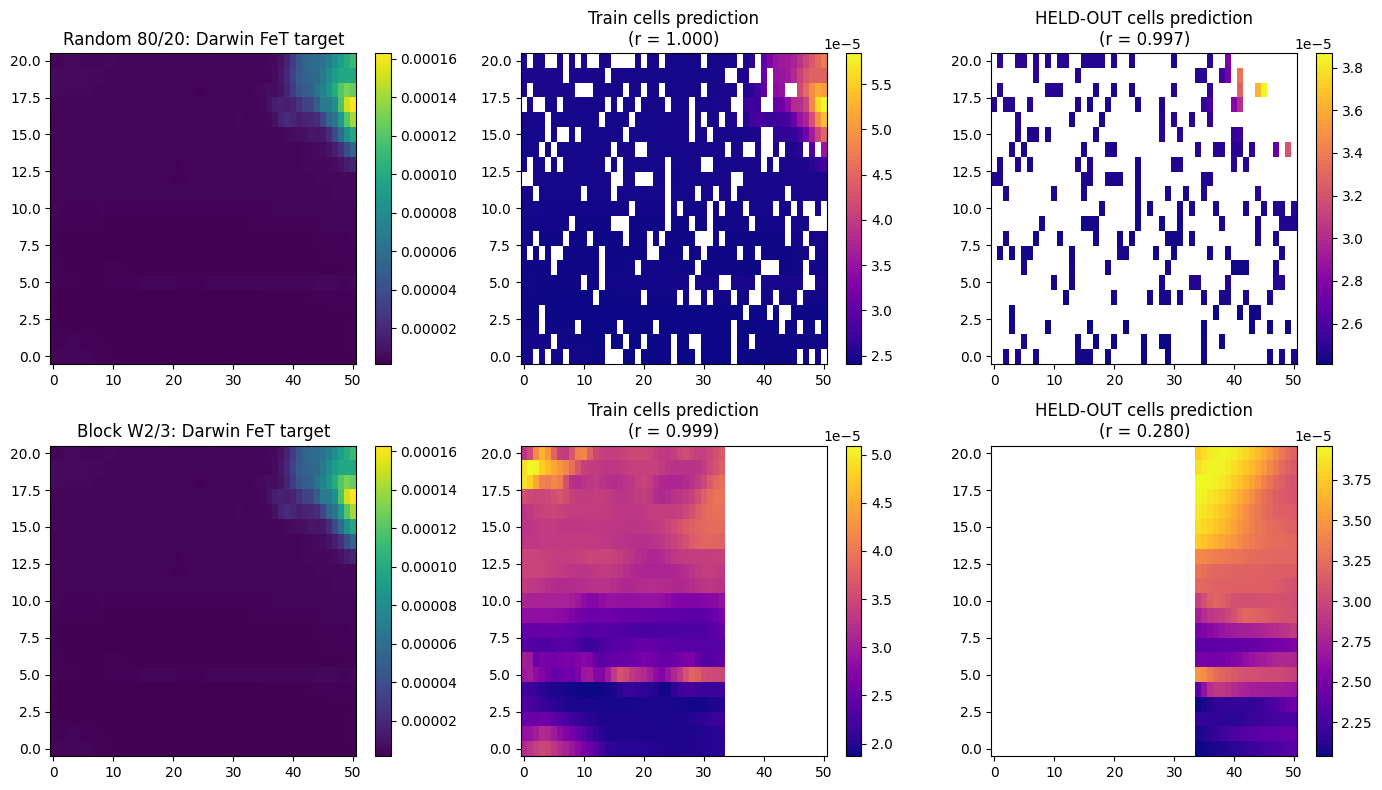

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fet_plot = np.where(ocean_mask, fet_binned, np.nan)

for row, (name, result, train_mask, test_mask) in enumerate([
    ("Random 80/20", r_random, train_mask_random, test_mask_random),
    ("Block W2/3", r_block, train_mask_block, test_mask_block),
]):
    pred = result["dfe_final"].numpy()
    pred_train = np.where(train_mask, pred, np.nan)
    pred_test = np.where(test_mask, pred, np.nan)
    pred_all = np.where(ocean_mask, pred, np.nan)
    
    im0 = axes[row, 0].imshow(fet_plot, origin="lower", aspect="auto", cmap="viridis")
    axes[row, 0].set_title(f"{name}: Darwin FeT target")
    plt.colorbar(im0, ax=axes[row, 0])

    im1 = axes[row, 1].imshow(pred_train, origin="lower", aspect="auto", cmap="plasma")
    r_t = safe_pearson_r(pred[train_mask], fet_binned[train_mask])
    axes[row, 1].set_title(f"Train cells prediction\n(r = {r_t.r:.3f})")
    plt.colorbar(im1, ax=axes[row, 1])

    im2 = axes[row, 2].imshow(pred_test, origin="lower", aspect="auto", cmap="plasma")
    r_h = safe_pearson_r(pred[test_mask], fet_binned[test_mask])
    axes[row, 2].set_title(f"HELD-OUT cells prediction\n(r = {r_h.r:.3f})")
    plt.colorbar(im2, ax=axes[row, 2])
plt.tight_layout(); plt.show()

## What this notebook tests — and what to do with the result

**The question:** does DINNDeep's r=1.000 in nb15 reflect a real env → Carroll-6 mapping, or near-memorization of the FeT field via degenerate parameter sets?

**The two CV splits answer different sub-questions:**

1. **Random 80/20** — interpolation. Held-out cells almost always have a train neighbour <2° away. If the network has learned ANY smooth env → params function, this should pass easily.
2. **Block W2/3** — extrapolation. The eastern third of the AOI is held out as a contiguous block. If the network is genuinely modeling a env → params relationship, the function evaluated at eastern-third env values should still produce reasonable predictions. If it's memorized, the predictions in unseen block territory will degrade.

**What stays unchanged regardless of CV outcome:**
- The structural-ceiling argument (DINN class > global-scalar class) — about parametric class, not network capacity
- The recovered Carroll-6 means in nb15 don't match Carroll's published values — box-model proxy is the recovery ceiling
- Box-model extension (DIC + ALK + carbonate chem) remains the highest-priority follow-up

**What the CV outcome changes:**
- **If both r values stay high** → DINNDeep is the new default architecture; roll out to nb11 / nb13 / nb14 with multi-channel input
- **If random passes but block fails** → DINNDeep is fine for interpolating gaps but not for extrapolating; report honestly and stay with DINN baseline for cross-basin claims
- **If both fail** → DINNDeep's r=1.000 was overfitting; report honestly and stay with DINN baseline

## Where this fits in the project arc

- 09–14: SST-only DINN fits across multiple (AOI × target) combos
- 15: architecture upgrade test on weakest fit (Track 1 v1.4)
- **16 (this notebook): cross-validation honesty check on nb15** — Track 1 v1.5
- After this: stop on local hardware, consolidate findings, email Jonathan, request MIT cluster access for the next phase (box-model extension + Track 2)